<a href="https://colab.research.google.com/github/lcandau/histopathology-clip-lab/blob/main/experiments/exp_05_ood_transfer/CLIP_OOD_NCT_CRC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# OOD transfer — LC25000-trained CLIP variants on NCT-CRC-HE

**Experiment:** `exp_05_ood_transfer` — RQ7 for *A Study on Foundational Visual-Language Models for Histopathology Image Analysis*.

**Purpose.** Test how well LC25000-trained CLIP variants transfer to **NCT-CRC-HE-7K** (Kather et al. 2019, Heidelberg), a colon histopathology dataset from a different institution and acquisition pipeline. Zero-shot — no fine-tuning on NCT.

We evaluate five variants on the same NCT test images, using the same five LC25000 class prompts. NCT's `NORM` (normal colon mucosa) maps to LC25000's `benign colon tissue`; NCT's `TUM` (colorectal adenocarcinoma epithelium) maps to `colon adenocarcinoma`. We restrict the eval to those two NCT classes (~1500 patches) so the comparison is a clean binary colon transfer; the remaining 7 NCT classes have no LC25000 equivalent.

**Variants compared:**

| Variant | Inputs | Backbone | Loss |
|---|---|---|---|
| Baseline CLIP | raw | frozen ResNet50 | CLIP InfoNCE |
| Macenko CLIP | Macenko-normalised | frozen ResNet50 | CLIP InfoNCE |
| Unfreeze30 CLIP | raw | last-30 unfrozen | CLIP InfoNCE |
| Macenko + Unfreeze30 CLIP | Macenko-normalised | last-30 unfrozen | CLIP InfoNCE |
| PLIP zero-shot | raw | frozen ViT-B/16 (PLIP) | n/a |

**What this measures.**
- In-distribution → OOD gap for each variant (compare against §4.2–§4.6 in-distribution numbers).
- Whether the levers that win in-distribution (Macenko, unfreeze30) also win OOD, or whether they overfit to LC25000-specific artifacts.
- Whether the best LC25000-trained model rivals a domain-pretrained foundation model (PLIP) without any pathology pretraining of its own.

**Reused machinery.**
- Existing checkpoints on Drive at `clip_histopathology/exp_01_baseline/{baseline,unfreeze30}/` and `clip_histopathology/exp_04_stain_normalization/{stain_macenko,stain_macenko_unfreeze30}/`.
- Same `MacenkoFitter` from `src/data/stain.py`, fit on the same LC25000 reference patch (`colon_n/colonn1.jpeg`) used at training time. At OOD time we apply the same fitter to NCT inputs before passing them to Macenko-trained variants.
- PLIP loaded from HuggingFace `vinid/plip`.

If a checkpoint is missing (e.g., the combo variant is still training), the corresponding cell prints a skip message and the final results table just omits that row.

## 0 — Setup

Clone the repo, install pinned dependencies, mount Drive. Same boilerplate as the training notebooks.

In [1]:
# --- Cell 0: bootstrap repo + dependencies + persistent storage ---
import os, sys, subprocess

REPO_URL = "https://github.com/lcandau/histopathology-clip-lab.git"
REPO_DIR = "/content/histopathology-clip-lab"
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        subprocess.run(["git", "clone", REPO_URL, REPO_DIR], check=True)
    else:
        subprocess.run(["git", "-C", REPO_DIR, "pull", "--ff-only"], check=True)
    subprocess.run(
        ["pip", "install", "-q", "-r", os.path.join(REPO_DIR, "requirements.txt")],
        check=True,
    )
    if REPO_DIR not in sys.path:
        sys.path.insert(0, REPO_DIR)

    from google.colab import drive
    drive.mount("/content/drive")
else:
    LOCAL_REPO_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
    if LOCAL_REPO_DIR not in sys.path:
        sys.path.insert(0, LOCAL_REPO_DIR)

print("In Colab:", IN_COLAB)
print("sys.path[0]:", sys.path[0])

Mounted at /content/drive
In Colab: True
sys.path[0]: /content/histopathology-clip-lab


## 1 — Imports and reproducibility

Note PLIP (variant 5) uses `transformers`, which is installed in `requirements.txt` for the PLIP zero-shot notebook.

In [2]:
# --- Cell 1: imports ---
import json
import math
import shutil
import tarfile
import time
import zipfile
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras
import keras_hub
from PIL import Image
from tqdm.auto import tqdm

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)

# Repository helpers.
from src.utils.paths import is_colab, repo_root, drive_root, run_dir, results_dir
from src.utils.repro import set_global_seed, enable_op_determinism
from src.data.lc25000 import CLASS_NAMES, NUM_CLASSES, INDEX_TO_NAME, discover_records, stratified_split
from src.data.stain import get_fitter
from src.prompts.templates import BASELINE_TEMPLATE, baseline_prompt

In [3]:
# --- Cell 2: reproducibility ---
SEED = 42
set_global_seed(SEED)
enable_op_determinism()

print("TF:", tf.__version__, "Keras:", keras.__version__, "KerasHub:", keras_hub.__version__)
print("GPUs:", tf.config.list_physical_devices("GPU"))

TF: 2.20.0 Keras: 3.14.0 KerasHub: 0.28.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2 — Configuration

The variant registry below is the single source of truth for which models we
evaluate. Each entry says where to find the checkpoint and whether to apply
Macenko normalisation to NCT inputs before inference. Missing checkpoints are
handled gracefully — useful if you launch this notebook while one of the
upstream training runs is still in flight.

In [4]:
# --- Cell 3: hyperparameters + paths ---
EXPERIMENT = "exp_05_ood_transfer"
VERSION = "nct_crc_he_7k"

IMG_SIZE   = 224
MAX_LEN    = 24                # matches training-time prompt length
EMBED_DIM  = 256
INIT_TEMP  = 0.07
BATCH_SIZE = 64                # inference-only, larger batch fine

# NCT-CRC-HE-7K (Kather 2019) — standardised held-out test set, 7,180 patches.
NCT_URL  = "https://zenodo.org/records/1214456/files/CRC-VAL-HE-7K.zip"
NCT_NAME = "CRC-VAL-HE-7K"

# NCT folder names → LC25000 prompt class names. Only these two NCT classes have
# direct LC25000 equivalents; the other seven (ADI/BACK/DEB/LYM/MUC/MUS/STR) are
# excluded from the primary eval. (Could be added later as a "rejected" class.)
NCT_TO_LC25000 = {
    "NORM": "benign colon tissue",
    "TUM":  "colon adenocarcinoma",
}

# LC25000 reference patch used to fit Macenko at training time.
# Same first-benign-colon-tissue image in canonical filename order.
LC25000_KAGGLE = "andrewmvd/lung-and-colon-cancer-histopathological-images"
LC25000_REF_REL = "lung_colon_image_set/colon_image_sets/colon_n/colonn1.jpeg"

# Drive / local caches.
DRIVE_ROOT_HERE = drive_root() / EXPERIMENT
DRIVE_OOD_ZIP   = drive_root() / "ood_datasets" / f"{NCT_NAME}.zip"
LOCAL_OOD_ROOT  = Path("/content/ood_data") if IN_COLAB else Path("/tmp/ood_data")
LOCAL_OOD_DIR   = LOCAL_OOD_ROOT / NCT_NAME

METRICS_DIR = results_dir("metrics")
PLOTS_DIR   = results_dir("plots")
CM_DIR      = results_dir("confusion_matrices")

# Variant registry: each row produces one evaluation. `checkpoint` is None for
# PLIP (handled separately). `normalize` controls whether to Macenko-normalise
# NCT inputs before feeding the model.
def _ckpt(experiment, version):
    return run_dir(experiment, version) / "weights.weights.h5"

VARIANTS = [
    {
        "key":        "baseline",
        "display":    "Baseline CLIP (raw, frozen)",
        "checkpoint": _ckpt("exp_01_baseline", "baseline"),
        "normalize":  False,
        "kind":       "clip",
    },
    {
        "key":        "stain_macenko",
        "display":    "Macenko CLIP (frozen)",
        "checkpoint": _ckpt("exp_04_stain_normalization", "stain_macenko"),
        "normalize":  True,
        "kind":       "clip",
    },
    {
        "key":        "unfreeze30",
        "display":    "Unfreeze30 CLIP (raw)",
        "checkpoint": _ckpt("exp_01_baseline", "unfreeze30"),
        "normalize":  False,
        "kind":       "clip",
    },
    {
        "key":        "stain_macenko_raw_input",
        "display":    "Macenko ckpt, raw NCT inputs",
        "checkpoint": _ckpt("exp_04_stain_normalization", "stain_macenko"),
        "normalize":  False,
        "kind":       "clip",
    },
    {
        "key":        "stain_macenko_unfreeze30",
        "display":    "Macenko + Unfreeze30 (best case)",
        "checkpoint": _ckpt("exp_04_stain_normalization", "stain_macenko_unfreeze30"),
        "normalize":  True,
        "kind":       "clip",
    },
    {
        "key":        "stain_macenko_unfreeze30_raw_input",
        "display":    "Combo ckpt, raw NCT inputs",
        "checkpoint": _ckpt("exp_04_stain_normalization", "stain_macenko_unfreeze30"),
        "normalize":  False,
        "kind":       "clip",
    },
    {
        "key":        "plip_zeroshot",
        "display":    "PLIP zero-shot",
        "checkpoint": None,
        "normalize":  False,
        "kind":       "plip",
    },
]

print("Variants registered:")
for v in VARIANTS:
    print(f"  - {v['key']:30s} normalize={v['normalize']}  kind={v['kind']}")
print()
print("Drive OOD zip path:", DRIVE_OOD_ZIP)
print("Local OOD extract path:", LOCAL_OOD_DIR)

Variants registered:
  - baseline                       normalize=False  kind=clip
  - stain_macenko                  normalize=True  kind=clip
  - unfreeze30                     normalize=False  kind=clip
  - stain_macenko_raw_input        normalize=False  kind=clip
  - stain_macenko_unfreeze30       normalize=True  kind=clip
  - stain_macenko_unfreeze30_raw_input normalize=False  kind=clip
  - plip_zeroshot                  normalize=False  kind=plip

Drive OOD zip path: /content/drive/MyDrive/clip_histopathology/ood_datasets/CRC-VAL-HE-7K.zip
Local OOD extract path: /content/ood_data/CRC-VAL-HE-7K


## 3 — Acquire NCT-CRC-HE-7K

Three-step ladder, mirrors the LC25000 precompute cache:

1. If local extract `/content/ood_data/CRC-VAL-HE-7K/` is complete, skip everything.
2. Else if the zip is already on Drive (`clip_histopathology/ood_datasets/CRC-VAL-HE-7K.zip`), extract to local.
3. Else download from Zenodo (~660 MB, ~2 min), save to Drive, then extract.

Net effect: first session pays the download once; every subsequent session is ~30 s for the extract.

In [5]:
# --- Cell 4: download / extract NCT-CRC-HE-7K ---
# Drive's FUSE mount is unreliable for large sequential reads on freshly-written
# files (Errno 107 mid-extract). Always extract from the local filesystem; use
# Drive purely as a cache for the zip across sessions.
import urllib.request

LOCAL_OOD_ROOT.mkdir(parents=True, exist_ok=True)
DRIVE_OOD_ZIP.parent.mkdir(parents=True, exist_ok=True)
LOCAL_OOD_ZIP = LOCAL_OOD_ROOT / f"{NCT_NAME}.zip"


IMAGE_EXTS = {".tif", ".tiff", ".jpg", ".jpeg", ".png"}
EXPECTED_PATCHES = 7180  # NCT-CRC-HE-7K total across all 9 classes

def _count_jpgs(root):
    if not root.exists():
        return 0
    return sum(1 for p in root.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS)


n_local = _count_jpgs(LOCAL_OOD_DIR)
if n_local >= EXPECTED_PATCHES:
    print(f"Local NCT cache complete at {LOCAL_OOD_DIR} ({n_local}/{EXPECTED_PATCHES} patches). Skipping extract.")
else:
    if n_local > 0:
        # Partial extract from a previous failed run (e.g. Drive FUSE crash mid-extract).
        # Wipe it and re-extract cleanly.
        print(f"Local cache is partial ({n_local}/{EXPECTED_PATCHES}). Removing and re-extracting.")
        shutil.rmtree(LOCAL_OOD_DIR, ignore_errors=True)
    # 1. Get the zip onto local disk (from Drive cache if present, else download).
    if DRIVE_OOD_ZIP.exists():
        size_mb = DRIVE_OOD_ZIP.stat().st_size / 1e6
        print(f"Found Drive cache: {DRIVE_OOD_ZIP} ({size_mb:.0f} MB). Copying to local...")
        t0 = time.time()
        shutil.copy2(DRIVE_OOD_ZIP, LOCAL_OOD_ZIP)
        print(f"  copied to {LOCAL_OOD_ZIP} in {time.time() - t0:.1f}s")
    else:
        print(f"Downloading {NCT_URL} -> {LOCAL_OOD_ZIP} ...")
        t0 = time.time()
        urllib.request.urlretrieve(NCT_URL, LOCAL_OOD_ZIP)
        size_mb = LOCAL_OOD_ZIP.stat().st_size / 1e6
        print(f"  downloaded {size_mb:.0f} MB in {time.time() - t0:.1f}s")
        # Cache to Drive for next session (best-effort: don't crash if Drive misbehaves).
        if IN_COLAB:
            print(f"Saving to Drive cache: {DRIVE_OOD_ZIP}")
            try:
                t0 = time.time()
                shutil.copy2(LOCAL_OOD_ZIP, DRIVE_OOD_ZIP)
                print(f"  saved in {time.time() - t0:.1f}s")
            except OSError as exc:
                print(f"  WARNING: could not write Drive cache ({exc}); next session will re-download.")

    # 2. Extract from local zip. Avoid Drive FUSE for the sequential read.
    print(f"Extracting -> {LOCAL_OOD_DIR}")
    t0 = time.time()
    with zipfile.ZipFile(LOCAL_OOD_ZIP, "r") as zf:
        zf.extractall(LOCAL_OOD_ROOT)
    print(f"  extracted in {time.time() - t0:.1f}s")

    # 3. Free local disk; the Drive zip remains as the durable cache.
    LOCAL_OOD_ZIP.unlink(missing_ok=True)

# Sanity-check the extracted structure. Walk the tree, find the deepest dir
# that contains all expected NCT classes as subdirs.
def _find_class_root(start, expected_classes):
    candidates = [start] + [p for p in start.rglob("*") if p.is_dir()]
    for cand in candidates:
        names = {p.name for p in cand.iterdir() if p.is_dir()}
        if set(expected_classes).issubset(names):
            return cand
    return None

NCT_CLASS_ROOT = _find_class_root(LOCAL_OOD_ROOT, list(NCT_TO_LC25000.keys()))
if NCT_CLASS_ROOT is None:
    print(f"Tree under {LOCAL_OOD_ROOT}:")
    for p in sorted(LOCAL_OOD_ROOT.rglob("*"))[:30]:
        print(f"  {p}")
    raise RuntimeError(
        f"Could not find a directory containing all NCT classes "
        f"{list(NCT_TO_LC25000.keys())} under {LOCAL_OOD_ROOT}. "
        f"Inspect the tree above and adjust NCT_NAME / extraction logic."
    )

print()
print(f"NCT class-containing root: {NCT_CLASS_ROOT}")
class_dirs = sorted(p for p in NCT_CLASS_ROOT.iterdir() if p.is_dir())
print(f"NCT classes found: {[p.name for p in class_dirs]}")
for cd in class_dirs:
    n = sum(1 for p in cd.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS)
    print(f"  {cd.name:5s}: {n} patches")

Found Drive cache: /content/drive/MyDrive/clip_histopathology/ood_datasets/CRC-VAL-HE-7K.zip (800 MB). Copying to local...
  copied to /content/ood_data/CRC-VAL-HE-7K.zip in 8.2s
Extracting -> /content/ood_data/CRC-VAL-HE-7K
  extracted in 10.9s

NCT class-containing root: /content/ood_data/CRC-VAL-HE-7K
NCT classes found: ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
  ADI  : 1338 patches
  BACK : 847 patches
  DEB  : 339 patches
  LYM  : 634 patches
  MUC  : 1035 patches
  MUS  : 592 patches
  NORM : 741 patches
  STR  : 421 patches
  TUM  : 1233 patches


## 4 — Build the OOD test set

Filter NCT to the two classes that have LC25000 equivalents (`NORM` → `benign colon tissue`, `TUM` → `colon adenocarcinoma`). Build a `(path, lc25000_class_index)` list and stratified-shuffle once for reproducible ordering. The other seven NCT classes are excluded from the primary eval.

In [6]:
# --- Cell 5: build OOD test set (NORM + TUM only) ---
LC25000_NAME_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}

def _list_class_images(class_dir):
    '''Case-insensitive image search, recurses one level if direct iterdir is empty.'''
    if not class_dir.exists():
        return []
    paths = [p for p in class_dir.iterdir() if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
    if not paths:
        paths = [p for p in class_dir.rglob("*") if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
    return sorted(paths)

ood_records = []
for nct_cls, lc_name in NCT_TO_LC25000.items():
    cls_dir = NCT_CLASS_ROOT / nct_cls
    paths = _list_class_images(cls_dir)
    if not paths:
        sample = list(cls_dir.iterdir())[:5] if cls_dir.exists() else []
        raise RuntimeError(
            f"No images found for NCT class {nct_cls} at {cls_dir}. "
            f"Directory exists: {cls_dir.exists()}. "
            f"First 5 entries: {[p.name for p in sample]}"
        )
    lc_idx = LC25000_NAME_TO_IDX[lc_name]
    for p in paths:
        ood_records.append({"path": p, "nct_class": nct_cls, "lc25000_idx": lc_idx, "lc25000_name": lc_name})

# Stratified shuffle (deterministic).
rng = np.random.default_rng(SEED)
ood_records = sorted(ood_records, key=lambda r: r["path"].name)
rng.shuffle(ood_records)

ood_paths = [r["path"] for r in ood_records]
y_true    = np.array([r["lc25000_idx"] for r in ood_records], dtype=np.int64)

print(f"OOD test set: {len(ood_records)} patches")
print(pd.Series([r["nct_class"] for r in ood_records]).value_counts().to_string())

OOD test set: 1974 patches
TUM     1233
NORM     741


## 5 — Visualise NCT samples (raw)

One representative patch per evaluated NCT class. Useful to eyeball the stain/colour distribution before any normalisation.

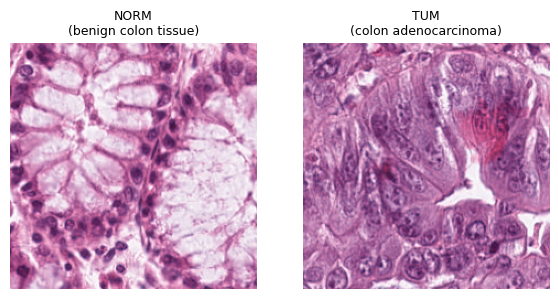

In [7]:
# --- Cell 6: visualize NCT samples ---
fig, axes = plt.subplots(1, len(NCT_TO_LC25000), figsize=(3 * len(NCT_TO_LC25000), 3))
if len(NCT_TO_LC25000) == 1:
    axes = [axes]
for ax, (nct_cls, lc_name) in zip(axes, NCT_TO_LC25000.items()):
    first = next((r["path"] for r in ood_records if r["nct_class"] == nct_cls), None)
    img = np.array(Image.open(first).convert("RGB"))
    ax.imshow(img)
    ax.set_title(f"{nct_cls}\n({lc_name})", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6 — Macenko fitter (same reference as training)

The Macenko-trained variants saw inputs normalised with respect to the *first benign-colon-tissue image in canonical filename order* in LC25000 (`colon_n/colonn1.jpeg`). To keep OOD inference consistent with training, we fit a Macenko fitter on the same reference patch here.

LC25000 is downloaded once via `kagglehub` (cached on the Colab runtime / Drive for subsequent runs). We only need that one reference patch — the rest of LC25000 is discarded after fitting.

In [8]:
# --- Cell 7: acquire LC25000 reference patch + fit Macenko ---
def _find_lc25000_reference():
    # 1. Quickest path: check if a prior LC25000 download is still on disk.
    for candidate_root in [
        Path("/kaggle/input") / Path(LC25000_KAGGLE).name,
        Path("/root/.cache/kagglehub/datasets") / LC25000_KAGGLE / "versions",
        Path.home() / ".cache/kagglehub/datasets" / LC25000_KAGGLE / "versions",
    ]:
        if candidate_root.exists():
            for path in candidate_root.rglob(LC25000_REF_REL.split("/")[-1]):
                if path.suffix.lower() in {".jpg", ".jpeg"} and "colon_n" in str(path):
                    return path
    # 2. Otherwise pull via kagglehub.
    try:
        import kagglehub
    except ImportError:
        subprocess.run(["pip", "install", "-q", "kagglehub"], check=True)
        import kagglehub
    print("Downloading LC25000 via kagglehub for Macenko reference (one-time on first run)...")
    root = Path(kagglehub.dataset_download(LC25000_KAGGLE))
    ref = root / LC25000_REF_REL
    assert ref.exists(), f"Reference patch not found at {ref}"
    return ref

ref_path = _find_lc25000_reference()
print(f"Macenko reference: {ref_path}")

ref_img = np.array(
    Image.open(ref_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
)

fitter = get_fitter("macenko").fit(ref_img)
print(f"Macenko fitter ready (target_stain_matrix_ shape: {fitter.target_stain_matrix_.shape})")

Using Colab cache for faster access to the 'lung-and-colon-cancer-histopathological-images' dataset.
Macenko reference: /kaggle/input/lung-and-colon-cancer-histopathological-images/lung_colon_image_set/colon_image_sets/colon_n/colonn1.jpeg
Macenko fitter ready (target_stain_matrix_ shape: (3, 2))


## 7 — Raw vs Macenko-normalised NCT samples

Quick sanity check that Macenko's re-render of NCT patches looks reasonable on the new dataset.

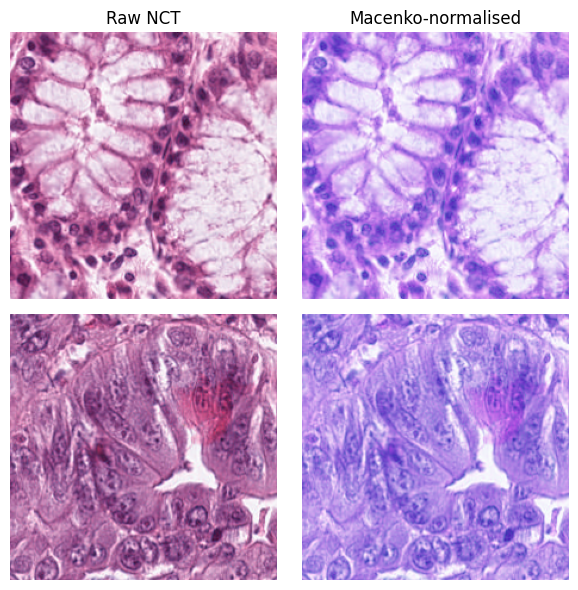

In [9]:
# --- Cell 8: raw vs Macenko-normalised NCT samples ---
fig, axes = plt.subplots(len(NCT_TO_LC25000), 2, figsize=(6, 3 * len(NCT_TO_LC25000)))
if len(NCT_TO_LC25000) == 1:
    axes = np.expand_dims(axes, 0)
for row, (nct_cls, lc_name) in enumerate(NCT_TO_LC25000.items()):
    first = next((r["path"] for r in ood_records if r["nct_class"] == nct_cls), None)
    raw  = np.array(Image.open(first).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
    norm = fitter.transform(raw)
    axes[row, 0].imshow(raw);  axes[row, 0].axis("off")
    axes[row, 1].imshow(norm); axes[row, 1].axis("off")
    axes[row, 0].set_ylabel(f"{nct_cls}\n→ {lc_name}", rotation=0, ha="right", va="center", fontsize=9)
axes[0, 0].set_title("Raw NCT");
axes[0, 1].set_title("Macenko-normalised");
plt.tight_layout()
plt.show()

## 8 — Class prompts and text preprocessor

Same five LC25000 prompts as the training notebooks. We keep all five (not just the two colon ones) so the model is evaluated under the exact same prompt regime it was trained with — what changes is the input distribution, not the label space.

In [10]:
# --- Cell 9: build the class prompts ---
class_prompts = [baseline_prompt(name) for name in CLASS_NAMES]
for i, p in enumerate(class_prompts):
    print(f"[{i}] {p}")

[0] A histopathology image of benign lung tissue.
[1] A histopathology image of lung adenocarcinoma.
[2] A histopathology image of lung squamous cell carcinoma.
[3] A histopathology image of benign colon tissue.
[4] A histopathology image of colon adenocarcinoma.


In [11]:
# --- Cell 10: text preprocessor ---
# Same single-call pattern as the training notebooks: pass the prompt tensor
# straight to the preprocessor and it returns a dict of token_ids /
# padding_mask / segment_ids tensors. (Unpacking into (tokens, labels,
# sample_weight) is only valid when you also pass labels; here we have only
# text, so the dict comes back as a single return value.)
text_pre = keras_hub.models.BertTextClassifierPreprocessor.from_preset(
    "bert_base_en_uncased", sequence_length=MAX_LEN
)
class_prompts_tf = tf.constant(class_prompts)
class_token_dict = text_pre(class_prompts_tf)
print({k: v.shape for k, v in class_token_dict.items()})

100%|██████████| 457/457 [00:00<00:00, 700kB/s]


100%|██████████| 761/761 [00:00<00:00, 1.37MB/s]


100%|██████████| 226k/226k [00:00<00:00, 82.7MB/s]


{'token_ids': TensorShape([5, 24]), 'padding_mask': TensorShape([5, 24]), 'segment_ids': TensorShape([5, 24])}


## 9 — CLIPModel architecture

Copied verbatim from the training notebooks (`CLIP_ResNet50_baseline.ipynb`, `CLIP_ResNet50_stain.ipynb`, `CLIP_ResNet50_unfreeze30.ipynb`, `CLIP_ResNet50_stain_unfreeze30.ipynb`). The architecture is identical across frozen and unfrozen variants — only the `trainable` flag on the image backbone differs, and that's irrelevant at inference time. So a single class can load weights from any of the four CLIP checkpoints.

In [12]:
# --- Cell 11: CLIPModel class ---
class CLIPModel(keras.Model):
    def __init__(self, img_backbone, text_backbone, embed_dim=EMBED_DIM, init_temp=INIT_TEMP):
        super().__init__()
        self.img_backbone = img_backbone
        self.text_backbone = text_backbone

        self.img_projection = keras.Sequential([
            keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
            keras.layers.LayerNormalization(dtype="float32"),
        ], name="img_projection")

        self.text_projection = keras.Sequential([
            keras.layers.Dense(embed_dim, use_bias=False, dtype="float32"),
            keras.layers.LayerNormalization(dtype="float32"),
        ], name="text_projection")

        self.logit_scale = self.add_weight(
            name="logit_scale",
            shape=(),
            initializer=keras.initializers.Constant(math.log(1.0 / init_temp)),
            trainable=True,
            dtype="float32",
        )

    def encode_image(self, images, training=False):
        features = self.img_backbone(images, training=False)
        if features.shape.rank == 4:
            features = tf.reduce_mean(features, axis=[1, 2])
        x = self.img_projection(features)
        x = tf.math.l2_normalize(x, axis=-1)
        return x

    def encode_text(self, token_dict, training=False):
        out = self.text_backbone(token_dict, training=False)
        if isinstance(out, dict):
            if "pooled_output" in out:
                features = out["pooled_output"]
            elif "sequence_output" in out:
                features = out["sequence_output"][:, 0, :]
            else:
                raise ValueError(f"Unexpected BERT output keys: {list(out.keys())}")
        else:
            features = out[:, 0, :] if out.shape.rank == 3 else out
        x = self.text_projection(features)
        x = tf.math.l2_normalize(x, axis=-1)
        return x

    def call(self, inputs, training=False):
        images, token_dict = inputs
        return {
            "image_embeddings": self.encode_image(images, training=training),
            "text_embeddings":  self.encode_text(token_dict, training=training),
        }

## 10 — Helper functions

- `build_clip_model()`: fresh CLIPModel with both backbones loaded from KerasHub and warmed up so `load_weights` succeeds.
- `load_ood_images(paths, normalize)`: decode NCT patches (resize to 224 if needed), optionally run Macenko, batch-stack.
- `evaluate_clip_variant(variant)`: load checkpoint, encode OOD images + class prompts, predict via cosine similarity, return metrics dict.

In [13]:
# --- Cell 12: helpers (build model, load images, evaluate variant) ---
def build_clip_model():
    image_backbone = keras_hub.models.Backbone.from_preset("resnet_50_imagenet")
    text_backbone  = keras_hub.models.Backbone.from_preset("bert_base_en_uncased")
    image_backbone.trainable = False
    text_backbone.trainable  = False
    model = CLIPModel(image_backbone, text_backbone)
    # Warm-up call so all weights are constructed before load_weights().
    dummy_imgs = tf.zeros((1, IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32)
    dummy_toks = {k: tf.constant(v[:1]) for k, v in class_token_dict.items()}
    _ = model((dummy_imgs, dummy_toks), training=False)
    return model


def load_ood_images(paths, normalize):
    out = np.empty((len(paths), IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
    for i, p in enumerate(tqdm(paths, desc=f"loading{' + macenko' if normalize else ''}")):
        img = np.array(Image.open(p).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
        if normalize:
            img = fitter.transform(img)
        out[i] = img.astype(np.float32)
    return out


def _encode_image_batches(model, images, batch_size=BATCH_SIZE):
    embs = []
    for i in range(0, len(images), batch_size):
        chunk = images[i:i + batch_size]
        emb = model.encode_image(tf.constant(chunk), training=False).numpy()
        embs.append(emb)
    return np.concatenate(embs, axis=0)


def evaluate_clip_variant(variant, image_cache=None):
    '''Run a CLIP variant on the OOD set. Returns metrics dict or None if checkpoint missing.'''
    ckpt = variant["checkpoint"]
    if not ckpt.exists():
        print(f"[{variant['key']}] SKIP — checkpoint not found at {ckpt}")
        return None
    print(f"[{variant['key']}] loading checkpoint {ckpt.name}")

    # 1. Load images (cached across variants that share normalisation setting).
    cache_key = "macenko" if variant["normalize"] else "raw"
    if image_cache is not None and cache_key in image_cache:
        images = image_cache[cache_key]
    else:
        images = load_ood_images(ood_paths, normalize=variant["normalize"])
        if image_cache is not None:
            image_cache[cache_key] = images

    # 2. Build model, load weights.
    model = build_clip_model()
    model.load_weights(str(ckpt))

    # 3. Encode prompts + images.
    txt_toks_tf = {k: tf.constant(v) for k, v in class_token_dict.items()}
    prompt_embs = model.encode_text(txt_toks_tf, training=False).numpy()
    image_embs  = _encode_image_batches(model, images)

    # 4. Predict via cosine similarity.
    logits = image_embs @ prompt_embs.T
    y_pred = logits.argmax(axis=1)

    return _compute_metrics(variant, y_pred, logits, image_embs=image_embs, prompt_embs=prompt_embs)


def _compute_metrics(variant, y_pred, logits, image_embs=None, prompt_embs=None):
    # Restrict to the two evaluated NCT classes' LC25000 indices.
    eval_idx = sorted({LC25000_NAME_TO_IDX[name] for name in NCT_TO_LC25000.values()})
    mask = np.isin(y_true, eval_idx)

    y_true_eval = y_true[mask]
    y_pred_eval = y_pred[mask]

    acc = accuracy_score(y_true_eval, y_pred_eval)
    bal = balanced_accuracy_score(y_true_eval, y_pred_eval)
    mf1 = f1_score(y_true_eval, y_pred_eval, labels=eval_idx, average="macro", zero_division=0)
    wf1 = f1_score(y_true_eval, y_pred_eval, labels=eval_idx, average="weighted", zero_division=0)

    report = classification_report(
        y_true_eval, y_pred_eval, labels=eval_idx,
        target_names=[INDEX_TO_NAME[i] for i in eval_idx],
        output_dict=True, zero_division=0,
    )

    print(f"  accuracy={acc:.4f}  balanced_acc={bal:.4f}  macro_f1={mf1:.4f}  weighted_f1={wf1:.4f}")

    return {
        "key":        variant["key"],
        "display":    variant["display"],
        "accuracy":   float(acc),
        "balanced_accuracy": float(bal),
        "macro_f1":   float(mf1),
        "weighted_f1": float(wf1),
        "report":     report,
        "y_pred":     y_pred,
        "logits":     logits,
        "image_embs": image_embs,
        "prompt_embs": prompt_embs,
    }

## 11 — Run the CLIP variants

Loop over the four LC25000-trained CLIP variants. Each evaluation:
1. Skip if checkpoint absent (so the cell is launchable mid-training).
2. Build a fresh CLIPModel + load weights.
3. Re-use a per-input-kind image cache (raw inputs decoded once, Macenko-normalised inputs decoded once).
4. Encode images and prompts, classify by argmax cosine similarity.
5. Store metrics + raw predictions for the aggregation step.

In [14]:
# --- Cell 13: run all 4 CLIP variants ---
clip_variants = [v for v in VARIANTS if v["kind"] == "clip"]
image_cache   = {}
results       = []

for variant in clip_variants:
    out = evaluate_clip_variant(variant, image_cache=image_cache)
    if out is not None:
        results.append(out)
    print()

print(f"Completed {len(results)} / {len(clip_variants)} CLIP variants.")

[baseline] loading checkpoint weights.weights.h5


loading:   0%|          | 0/1974 [00:00<?, ?it/s]

100%|██████████| 841/841 [00:00<00:00, 1.47MB/s]


100%|██████████| 90.3M/90.3M [00:00<00:00, 138MB/s]


100%|██████████| 418M/418M [00:03<00:00, 144MB/s]


...

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  accuracy=0.0922  balanced_acc=0.0988  macro_f1=0.1538  weighted_f1=0.1489

[stain_macenko_unfreeze30] loading checkpoint weights.weights.h5


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


  accuracy=0.0000  balanced_acc=0.0000  macro_f1=0.0000  weighted_f1=0.0000

[stain_macenko_unfreeze30_raw_input] loading checkpoint weights.weights.h5
  accuracy=0.1449  balanced_acc=0.1216  macro_f1=0.2011  weighted_f1=0.2385

Completed 6 / 6 CLIP variants.


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## 12 — PLIP zero-shot

Different codepath: PLIP is loaded via HuggingFace `transformers` (model + processor pair), evaluated with its own preprocessing pipeline. Same OOD images, same five LC25000 prompts (the model never trained on them — it's true zero-shot).

In [15]:
# --- Cell 14: PLIP zero-shot evaluation ---
# We bypass plip_model.get_text_features() / get_image_features() because the
# vinid/plip build on HuggingFace returns a BaseModelOutputWithPooling object
# instead of the projected feature tensor from those helpers. Calling
# text_model + text_projection (and vision_model + visual_projection) directly
# is robust across PLIP variants — same pattern used in CLIP_PLIP_zeroshot.ipynb.
plip_variant = next(v for v in VARIANTS if v["kind"] == "plip")
print(f"[{plip_variant['key']}] running PLIP zero-shot on OOD set")

try:
    import torch
    from transformers import CLIPModel as HFCLIPModel, CLIPProcessor
except ImportError:
    subprocess.run(["pip", "install", "-q", "transformers", "torch"], check=True)
    import torch
    from transformers import CLIPModel as HFCLIPModel, CLIPProcessor

PLIP_MODEL_NAME = "vinid/plip"
plip_model = HFCLIPModel.from_pretrained(PLIP_MODEL_NAME)
plip_proc  = CLIPProcessor.from_pretrained(PLIP_MODEL_NAME)
plip_model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
plip_model = plip_model.to(device)

# Encode prompts once via text_model + text_projection (avoiding get_text_features quirk).
with torch.no_grad():
    text_inputs = plip_proc(text=class_prompts, return_tensors="pt", padding=True).to(device)
    text_outputs = plip_model.text_model(
        input_ids=text_inputs.input_ids,
        attention_mask=text_inputs.attention_mask,
    )
    plip_text = plip_model.text_projection(text_outputs.pooler_output)
    plip_text = plip_text / plip_text.norm(dim=-1, keepdim=True)
    plip_text = plip_text.cpu().numpy()

# Encode images in batches via vision_model + visual_projection.
plip_image_embs = []
with torch.no_grad():
    for i in tqdm(range(0, len(ood_paths), BATCH_SIZE), desc="PLIP encode images"):
        chunk_paths = ood_paths[i:i + BATCH_SIZE]
        pil_imgs = [Image.open(p).convert("RGB") for p in chunk_paths]
        inputs = plip_proc(images=pil_imgs, return_tensors="pt").to(device)
        vision_outputs = plip_model.vision_model(pixel_values=inputs.pixel_values)
        feats = plip_model.visual_projection(vision_outputs.pooler_output)
        feats = feats / feats.norm(dim=-1, keepdim=True)
        plip_image_embs.append(feats.cpu().numpy())
plip_image_embs = np.concatenate(plip_image_embs, axis=0)

plip_logits = plip_image_embs @ plip_text.T
plip_pred   = plip_logits.argmax(axis=1)

plip_metrics = _compute_metrics(plip_variant, plip_pred, plip_logits,
                                image_embs=plip_image_embs, prompt_embs=plip_text)
results.append(plip_metrics)

[plip_zeroshot] running PLIP zero-shot on OOD set


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.46k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

PLIP encode images:   0%|          | 0/31 [00:00<?, ?it/s]

  accuracy=0.5572  balanced_acc=0.6095  macro_f1=0.6610  weighted_f1=0.6306


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:2524: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


## 13 — Aggregate results

Side-by-side comparison of all variants on the same NCT OOD set. The headline numbers go straight into Table 4.x in `report/results/results.tex`.

In [16]:
# --- Cell 15: aggregate results table ---
table_rows = []
for r in results:
    table_rows.append({
        "variant":            r["display"],
        "accuracy":           r["accuracy"],
        "balanced_accuracy":  r["balanced_accuracy"],
        "macro_f1":           r["macro_f1"],
        "weighted_f1":        r["weighted_f1"],
    })

df = pd.DataFrame(table_rows).set_index("variant")
print("OOD results on NCT-CRC-HE-7K (NORM + TUM subset, ~1500 patches):\n")
print(df.round(4).to_string())

OOD results on NCT-CRC-HE-7K (NORM + TUM subset, ~1500 patches):

                                  accuracy  balanced_accuracy  macro_f1  weighted_f1
variant                                                                             
Baseline CLIP (raw, frozen)         0.1327             0.1399    0.2134       0.2096
Macenko CLIP (frozen)               0.0000             0.0000    0.0000       0.0000
Unfreeze30 CLIP (raw)               0.3865             0.3167    0.3309       0.3966
Macenko ckpt, raw NCT inputs        0.0922             0.0988    0.1538       0.1489
Macenko + Unfreeze30 (best case)    0.0000             0.0000    0.0000       0.0000
Combo ckpt, raw NCT inputs          0.1449             0.1216    0.2011       0.2385
PLIP zero-shot                      0.5572             0.6095    0.6610       0.6306


In [17]:
# --- Cell 16: persist OOD metrics JSON ---
ood_metrics_path = METRICS_DIR / f"ood_nct_{VERSION}_results.json"
ood_metrics_path.parent.mkdir(parents=True, exist_ok=True)

persistable = []
for r in results:
    persistable.append({
        "key":               r["key"],
        "display":           r["display"],
        "accuracy":          r["accuracy"],
        "balanced_accuracy": r["balanced_accuracy"],
        "macro_f1":          r["macro_f1"],
        "weighted_f1":       r["weighted_f1"],
        "per_class":         {
            cname: {k: v for k, v in vals.items()}
            for cname, vals in r["report"].items()
            if cname in NCT_TO_LC25000.values()
        },
    })

ood_metrics_path.write_text(json.dumps({
    "dataset":     NCT_NAME,
    "n_patches":   int(np.isin(y_true, list({LC25000_NAME_TO_IDX[n] for n in NCT_TO_LC25000.values()})).sum()),
    "nct_classes_evaluated": list(NCT_TO_LC25000.keys()),
    "variants":    persistable,
}, indent=2))
print(f"Saved -> {ood_metrics_path}")

Saved -> /content/histopathology-clip-lab/results/metrics/ood_nct_nct_crc_he_7k_results.json


## 14 — Confusion matrices

One row-normalised confusion matrix per variant, restricted to the two evaluated LC25000 classes (`benign colon tissue`, `colon adenocarcinoma`). Cell intensity = fraction of true-class samples predicted as the column label.

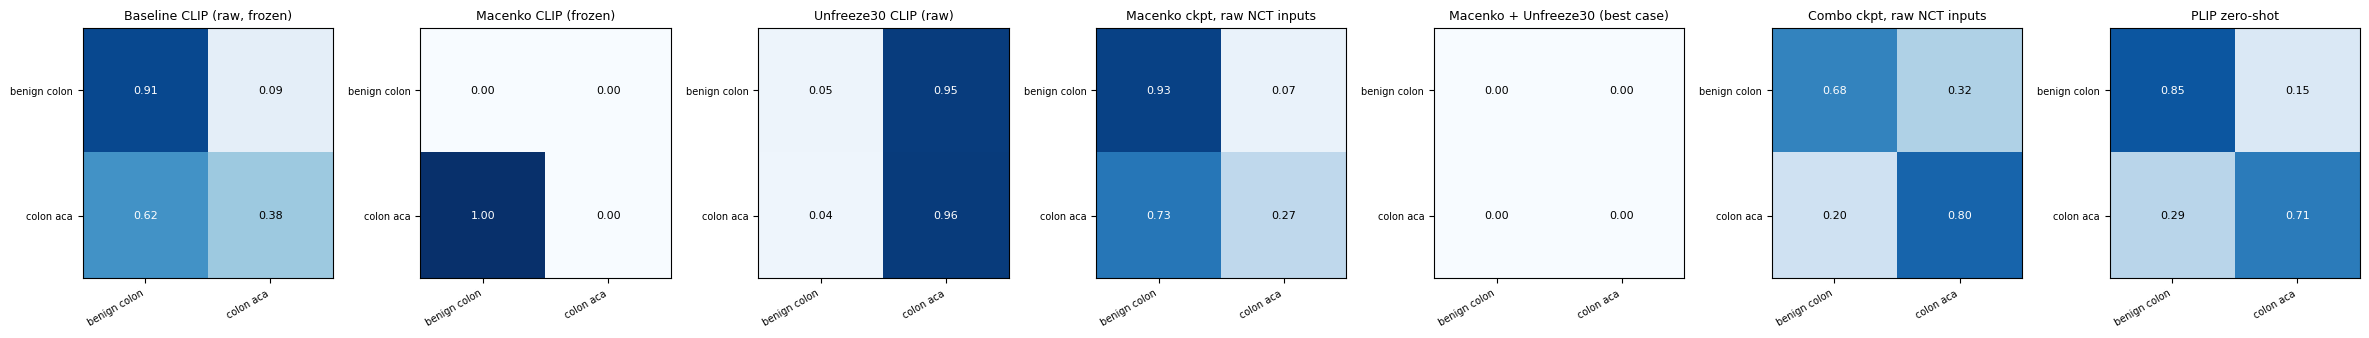

Saved -> /content/histopathology-clip-lab/results/confusion_matrices/ood_nct_nct_crc_he_7k_confusion_matrices.png


In [18]:
# --- Cell 17: confusion matrix grid ---
eval_idx   = sorted({LC25000_NAME_TO_IDX[name] for name in NCT_TO_LC25000.values()})
eval_names = [INDEX_TO_NAME[i] for i in eval_idx]
mask       = np.isin(y_true, eval_idx)

n = len(results)
fig, axes = plt.subplots(1, n, figsize=(3.4 * n, 3.4))
if n == 1:
    axes = [axes]

for ax, r in zip(axes, results):
    cm = confusion_matrix(y_true[mask], r["y_pred"][mask], labels=eval_idx, normalize="true")
    im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(len(eval_idx)))
    ax.set_yticks(range(len(eval_idx)))
    ax.set_xticklabels([n.replace(" tissue", "").replace(" adenocarcinoma", " aca") for n in eval_names], rotation=30, ha="right", fontsize=7)
    ax.set_yticklabels([n.replace(" tissue", "").replace(" adenocarcinoma", " aca") for n in eval_names], fontsize=7)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                    color="white" if cm[i, j] > 0.5 else "black", fontsize=8)
    ax.set_title(r["display"], fontsize=9)
plt.tight_layout()

cm_out = CM_DIR / f"ood_nct_{VERSION}_confusion_matrices.png"
plt.savefig(cm_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {cm_out}")

## 14b — UMAP grid (per-variant)

Per-variant UMAP of OOD image embeddings, coloured by NCT true class (NORM vs TUM), with the five LC25000 class-prompt embeddings overlaid as markers. Same shared-UMAP-with-prompts pattern as the in-distribution figures in §4.2–§4.6, but the image points now come from the external NCT-CRC-HE test set.

What to read off:
- Are NORM and TUM separable in each variant's embedding space, even when the classifier head is wrong?
- Do the five LC25000 prompt markers sit near the colon clusters they describe, or have they drifted?
- Which variant has the cleanest NCT class structure — does it match the headline accuracy?

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr

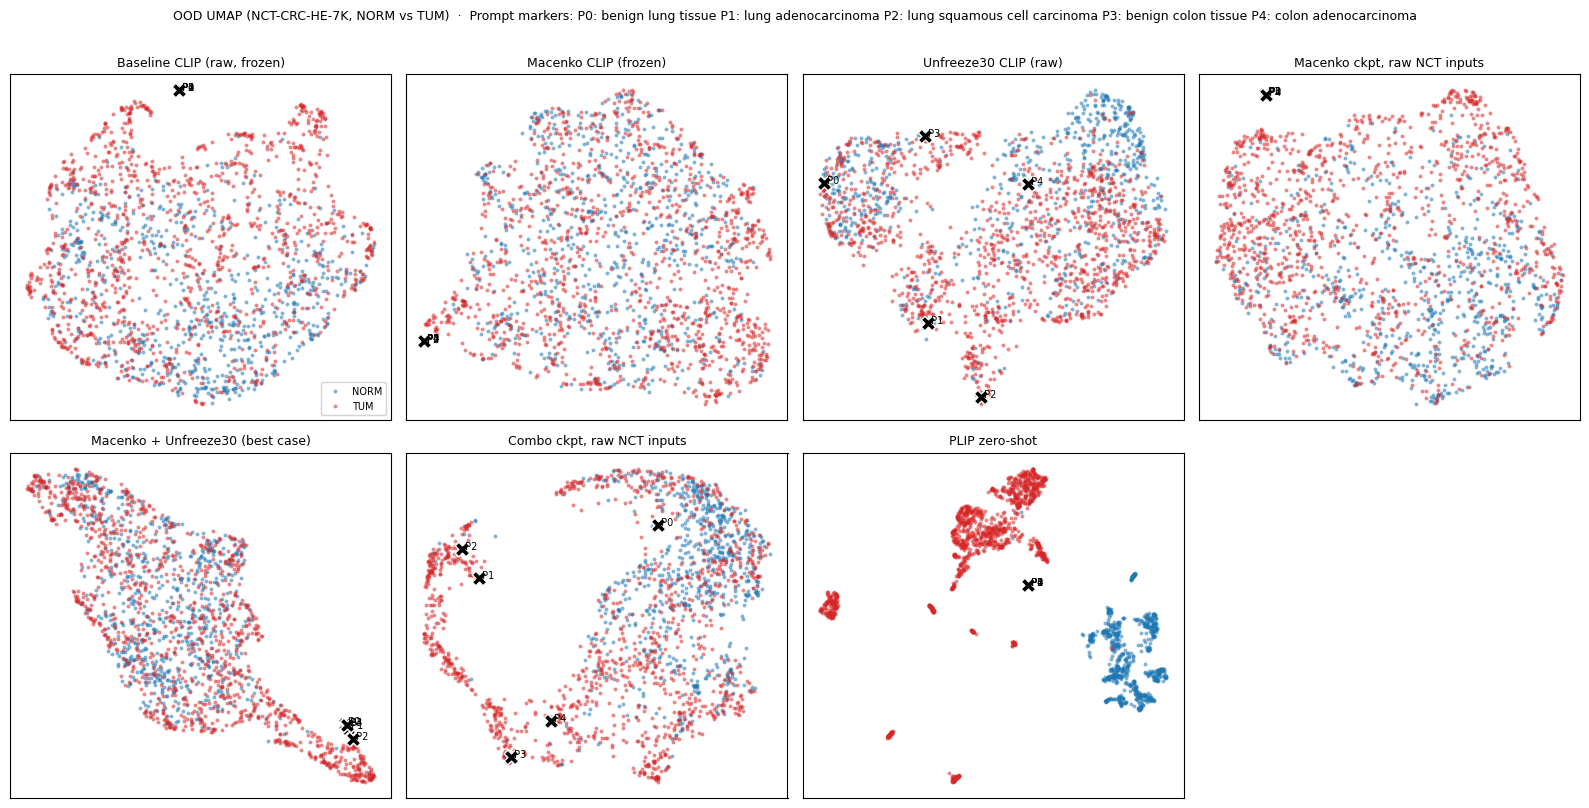

Saved -> /content/histopathology-clip-lab/results/plots/ood_nct_nct_crc_he_7k_umap_grid.png


In [19]:
# --- Cell 18: per-variant UMAP grid on the OOD set ---
import umap

eval_idx   = sorted({LC25000_NAME_TO_IDX[name] for name in NCT_TO_LC25000.values()})
mask       = np.isin(y_true, eval_idx)
nct_classes = np.array([r["nct_class"] for r in ood_records])
nct_eval    = nct_classes[mask]
nct_palette = {"NORM": "tab:blue", "TUM": "tab:red"}

# Layout: 4 columns x ceil(n/4) rows. With 7 results that's 4x2 with one empty slot.
n      = len(results)
n_cols = 4
n_rows = (n + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.0 * n_cols, 4.0 * n_rows))
axes = np.atleast_2d(axes)

for k, r in enumerate(results):
    ax = axes[k // n_cols, k % n_cols]
    img_embs    = r["image_embs"][mask]                   # (N_eval, D)
    prompt_embs = r["prompt_embs"]                         # (5, D)
    # Shared fit on image + prompt embeddings (cosine metric).
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED)
    joint   = reducer.fit_transform(np.vstack([img_embs, prompt_embs]))
    img_2d   = joint[:len(img_embs)]
    prompt_2d = joint[len(img_embs):]

    # Image scatter coloured by NCT class.
    for nct_cls, colour in nct_palette.items():
        sel = nct_eval == nct_cls
        ax.scatter(img_2d[sel, 0], img_2d[sel, 1], s=8, c=colour, alpha=0.55, label=nct_cls, linewidths=0)
    # Prompt markers labelled with LC25000 class index.
    for j, (px, py) in enumerate(prompt_2d):
        ax.scatter(px, py, s=110, c="black", marker="X", edgecolors="white", linewidths=1.0, zorder=3)
        ax.text(px, py, f" P{j}", fontsize=7, color="black", zorder=4)
    ax.set_title(r["display"], fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])
    if k == 0:
        ax.legend(loc="lower right", fontsize=7, framealpha=0.85)

# Hide unused panels.
for k in range(n, n_rows * n_cols):
    axes[k // n_cols, k % n_cols].axis("off")

# Caption-style note on prompt indices.
note = " ".join(f"P{j}: {INDEX_TO_NAME[j]}" for j in range(NUM_CLASSES))
fig.suptitle(f"OOD UMAP (NCT-CRC-HE-7K, NORM vs TUM)  ·  Prompt markers: {note}", fontsize=9, y=1.005)
plt.tight_layout()

umap_out = PLOTS_DIR / f"ood_nct_{VERSION}_umap_grid.png"
plt.savefig(umap_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {umap_out}")

## 14c — Cross-distribution UMAP: do NCT colon embeddings land near LC25000 colon embeddings?

The single-distribution UMAP above (\S\ref{fig:ood-umap}, Cell 18) shows whether NORM and TUM separate from each other inside the OOD set. This cell asks a sharper question: when LC25000 test patches and NCT NORM/TUM patches are projected into the same 2D embedding space, do the *new* colon embeddings cluster near the *old* colon embeddings, or do they drift into the lung region (a stronger sign of representation failure)?

We fit one UMAP per variant on the concatenation `(LC25000 test, NCT NORM+TUM)` and colour points by their source dataset and class group:

- LC25000 lung (any of the 3 lung classes): orange small circles
- LC25000 colon (benign + adeno): green small circles
- NCT NORM: dark blue triangles
- NCT TUM: dark red triangles

For LC25000, we use the same deterministic stratified test split as training (seed = 42), reconstructed by re-discovering records under the current Colab-session kagglehub root (so paths resolve correctly regardless of the cache location). For each variant, LC25000 inputs are normalised exactly as that variant configures (i.e., raw inputs for raw-trained variants, Macenko-normalised for Macenko-trained variants, raw for the disambiguation rows — same convention as the OOD inputs).

LC25000 test split: 2500 patches


LC25000 load:   0%|          | 0/2500 [00:00<?, ?it/s]

[baseline] encoding LC25000 test set...


LC25000 load + macenko:   0%|          | 0/2500 [00:00<?, ?it/s]

[stain_macenko] encoding LC25000 test set...
[unfreeze30] encoding LC25000 test set...
[stain_macenko_raw_input] encoding LC25000 test set...
[stain_macenko_unfreeze30] encoding LC25000 test set...
[stain_macenko_unfreeze30_raw_input] encoding LC25000 test set...
PLIP encoding LC25000 (2500 patches)...


PLIP encode LC25000:   0%|          | 0/40 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr

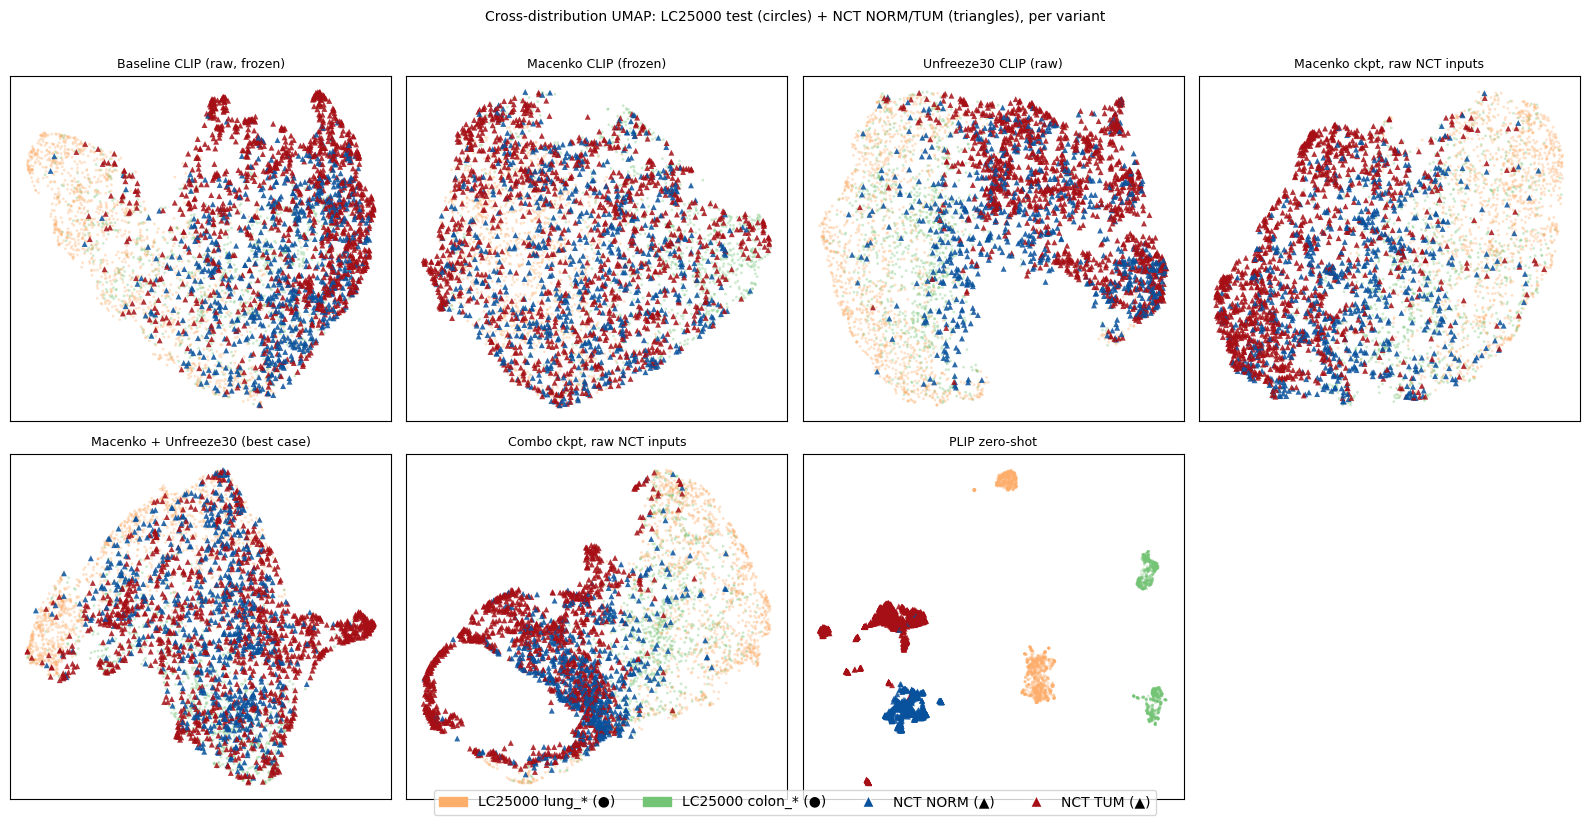

Saved -> /content/histopathology-clip-lab/results/plots/ood_nct_nct_crc_he_7k_cross_distribution_umap.png


In [21]:
# --- Cell 19: cross-distribution UMAP (LC25000 test + NCT NORM/TUM, per variant) ---
import umap
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

# 1. Reconstruct the LC25000 test split for this Colab session.
#    ref_path was set in Cell 7 by _find_lc25000_reference(); its .parents[3]
#    is the LC25000 dataset root that discover_records() expects.
lc25000_root = ref_path.parents[3]
lc_paths_all, lc_indices_all = discover_records(lc25000_root)
lc_split = stratified_split(
    lc_paths_all, lc_indices_all,
    val_fraction=0.10, test_fraction=0.10, seed=SEED,
)
lc_test_paths   = [Path(p) for p in lc_split["test_paths"]]
lc_test_indices = np.array(lc_split["test_indices"], dtype=np.int64)
print(f"LC25000 test split: {len(lc_test_paths)} patches")

def _load_lc_images(paths, normalize):
    out = np.empty((len(paths), IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
    for i, p in enumerate(tqdm(paths, desc=f"LC25000 load{' + macenko' if normalize else ''}")):
        img = np.array(Image.open(p).convert("RGB").resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR))
        if normalize:
            img = fitter.transform(img)
        out[i] = img.astype(np.float32)
    return out


# 2. Encode LC25000 test set with each CLIP variant. Image cache shared by input kind.
lc_image_cache_x = {}
lc_embs_per_variant = {}
for variant in (v for v in VARIANTS if v["kind"] == "clip"):
    if not variant["checkpoint"].exists():
        continue
    cache_key = "macenko" if variant["normalize"] else "raw"
    if cache_key not in lc_image_cache_x:
        lc_image_cache_x[cache_key] = _load_lc_images(lc_test_paths, normalize=variant["normalize"])
    images = lc_image_cache_x[cache_key]
    print(f"[{variant['key']}] encoding LC25000 test set...")
    model = build_clip_model()
    model.load_weights(str(variant["checkpoint"]))
    lc_embs_per_variant[variant["key"]] = _encode_image_batches(model, images)

# 3. PLIP encoding of LC25000 (separate codepath with HF processor).
plip_results = [r for r in results if r["key"] == "plip_zeroshot"]
if plip_results:
    print(f"PLIP encoding LC25000 ({len(lc_test_paths)} patches)...")
    plip_lc_embs = []
    with torch.no_grad():
        for i in tqdm(range(0, len(lc_test_paths), BATCH_SIZE), desc="PLIP encode LC25000"):
            chunk = lc_test_paths[i:i + BATCH_SIZE]
            pil_imgs = [Image.open(p).convert("RGB") for p in chunk]
            inputs = plip_proc(images=pil_imgs, return_tensors="pt").to(device)
            vis    = plip_model.vision_model(pixel_values=inputs.pixel_values)
            feats  = plip_model.visual_projection(vis.pooler_output)
            feats  = feats / feats.norm(dim=-1, keepdim=True)
            plip_lc_embs.append(feats.cpu().numpy())
    lc_embs_per_variant["plip_zeroshot"] = np.concatenate(plip_lc_embs, axis=0)

# 4. Colour scheme: tissue-group + dataset-of-origin.
COLON_IDX = {LC25000_NAME_TO_IDX[n] for n in NCT_TO_LC25000.values()}
COLOR_LC25000_LUNG  = "#fdae6b"  # warm orange   — LC25000 lung_*
COLOR_LC25000_COLON = "#74c476"  # green         — LC25000 colon_*
COLOR_NCT_NORM      = "#08519c"  # dark blue     — NCT NORM (= benign colon)
COLOR_NCT_TUM       = "#a50f15"  # dark red      — NCT TUM (= colon adeno)

lc_is_colon = np.isin(lc_test_indices, list(COLON_IDX))
lc_colors   = np.where(lc_is_colon, COLOR_LC25000_COLON, COLOR_LC25000_LUNG)

eval_idx = sorted(COLON_IDX)
mask_nct = np.isin(y_true, eval_idx)
nct_classes_eval = np.array([r["nct_class"] for r in ood_records])[mask_nct]
nct_colors = np.where(nct_classes_eval == "NORM", COLOR_NCT_NORM, COLOR_NCT_TUM)

# 5. Per-variant fit and 4x2 grid plot.
n      = len(results)
n_cols = 4
n_rows = (n + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.0 * n_cols, 4.0 * n_rows))
axes = np.atleast_2d(axes)

for k, r in enumerate(results):
    ax = axes[k // n_cols, k % n_cols]
    if r["key"] not in lc_embs_per_variant:
        ax.set_title(f"{r['display']}\n(no checkpoint)", fontsize=8)
        ax.axis("off"); continue
    lc_embs  = lc_embs_per_variant[r["key"]]
    nct_embs = r["image_embs"][mask_nct]
    reducer  = umap.UMAP(n_neighbors=15, min_dist=0.1, metric="cosine", random_state=SEED)
    joint    = reducer.fit_transform(np.vstack([lc_embs, nct_embs]))
    lc_2d   = joint[:len(lc_embs)]
    nct_2d  = joint[len(lc_embs):]
    ax.scatter(lc_2d[:, 0], lc_2d[:, 1], s=4, c=lc_colors, alpha=0.35, linewidths=0)
    ax.scatter(nct_2d[:, 0], nct_2d[:, 1], s=18, c=nct_colors, alpha=0.85, marker="^", linewidths=0)
    ax.set_title(r["display"], fontsize=9)
    ax.set_xticks([]); ax.set_yticks([])

for k in range(n, n_rows * n_cols):
    axes[k // n_cols, k % n_cols].axis("off")

handles = [
    mpatches.Patch(color=COLOR_LC25000_LUNG,  label="LC25000 lung_* (●)"),
    mpatches.Patch(color=COLOR_LC25000_COLON, label="LC25000 colon_* (●)"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor=COLOR_NCT_NORM, markersize=9, label="NCT NORM (▲)"),
    Line2D([0], [0], marker="^", color="w", markerfacecolor=COLOR_NCT_TUM,  markersize=9, label="NCT TUM (▲)"),
]
fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=10, bbox_to_anchor=(0.5, -0.01))
plt.suptitle("Cross-distribution UMAP: LC25000 test (circles) + NCT NORM/TUM (triangles), per variant", fontsize=10, y=1.005)
plt.tight_layout()

cross_out = PLOTS_DIR / f"ood_nct_{VERSION}_cross_distribution_umap.png"
plt.savefig(cross_out, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved -> {cross_out}")

## 15 — Summary

The aggregated table above and the saved JSON/PNG artifacts feed §4.8 in the thesis. The headline questions:

- Which LC25000-trained variant transfers best to NCT?
- Does Macenko help OOD as well as in-distribution?
- Does feature adaptation (unfreeze30) overfit to LC25000 or generalise?
- Does the best LC25000-trained model rival PLIP's domain-pretrained zero-shot?